# The transient universe

In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [2]:
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import uniform
import scipy.stats

import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc

import warnings

import corner

Data is a (100 x 3) array, containing some time-series measurements from a transient phenomenon: we have time, flux and error on flux (homoscedastic)

visualize data

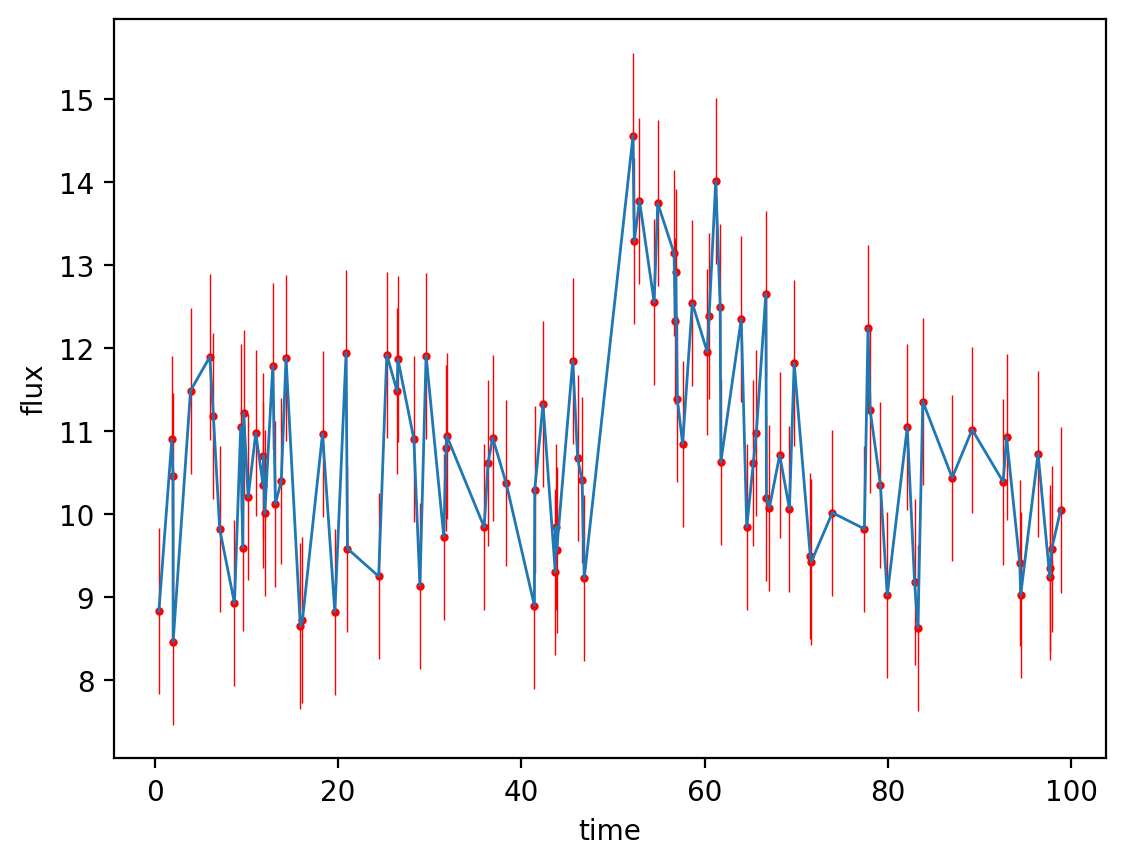

In [3]:
data=np.load('transient.npy')

time,flux,error=data.T
plt.scatter(time,flux,s=4,color='red')
plt.errorbar(time,flux,error,ecolor='red',elinewidth=0.5, lw=1)
plt.xlabel("time")
plt.ylabel("flux");

We will compare the results after fitting two models: the burst model of L11 and a gaussian model

In [4]:
def burst(par, t):
    b,A,t0,alpha=par 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

def gauss(par,t):
    b,A,t0,sigma=par     
    return b+A*np.exp(-(((t-t0)/sigma)**2 ) / 2)

In [5]:
bmin,bmax=0,50
Amin,Amax=0,50
t0min,t0max = 0,100
alphamin,alphamax=np.exp(-5),np.exp(5)
sigmamin,sigmamax=np.exp(-2),np.exp(2)

I write the likelihood and the prior (I will use dynesty, so I need to transform parameter space into a unit hypercube for priors)

I should keep track of the normalization in the loglikelihood, but since I'm only interested in the ratio between evidences, normalizations will cancel out

In [6]:
def loglike(par, data, model):
    t, f, sigma_f = data.T
    if model =='burst':
        f_fit = burst(par, t)
    elif model == 'gauss':
        f_fit = gauss(par, t)
        
    return -0.5 * np.sum((f-f_fit)**2 / sigma_f**2 ) 


def ptform(u,model):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u
    
    x[0] = scipy.stats.uniform(loc=bmin,scale=bmax-bmin).ppf(u[0])
    x[1] = scipy.stats.uniform(loc=Amin,scale=Amax-Amin).ppf(u[1])
    x[2] = scipy.stats.uniform(loc=t0min,scale=t0max-t0min).ppf(u[2])
   
    if model =='burst':
        x[3] = scipy.stats.loguniform.ppf(u[3],alphamin,alphamax)
    elif model =='gauss':
        x[3] = scipy.stats.loguniform.ppf(u[3],sigmamin,sigmamax)

    return x

# Burst profile model

First I try to reproduce the results of L11 using dynesty and the burst model to fit data

In [7]:
ndim = 4

with warnings.catch_warnings(): 
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)

    sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'burst'],ptform_args=['burst'],nlive=1000)
    sampler.run_nested()
    sresults = sampler.results

7783it [08:00,  7.33it/s, bound: 63 | nc: 62 | ncall: 129927 | eff(%):  5.990 | loglstar:   -inf < -87.066 <    inf | logz: -93.440 +/-  0.076 | dlogz: 36.467 >  1.009]     /Users/beatricetonello/opt/anaconda3/lib/python3.11/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
14683it [14:25, 16.96it/s, +1000 | bound: 130 | nc: 1 | ncall: 231060 | eff(%):  6.817 | loglstar:   -inf < -48.776 <    inf | logz: -63.346 +/-  0.123 | dlogz:  0.001 >  1.009]


check runplots

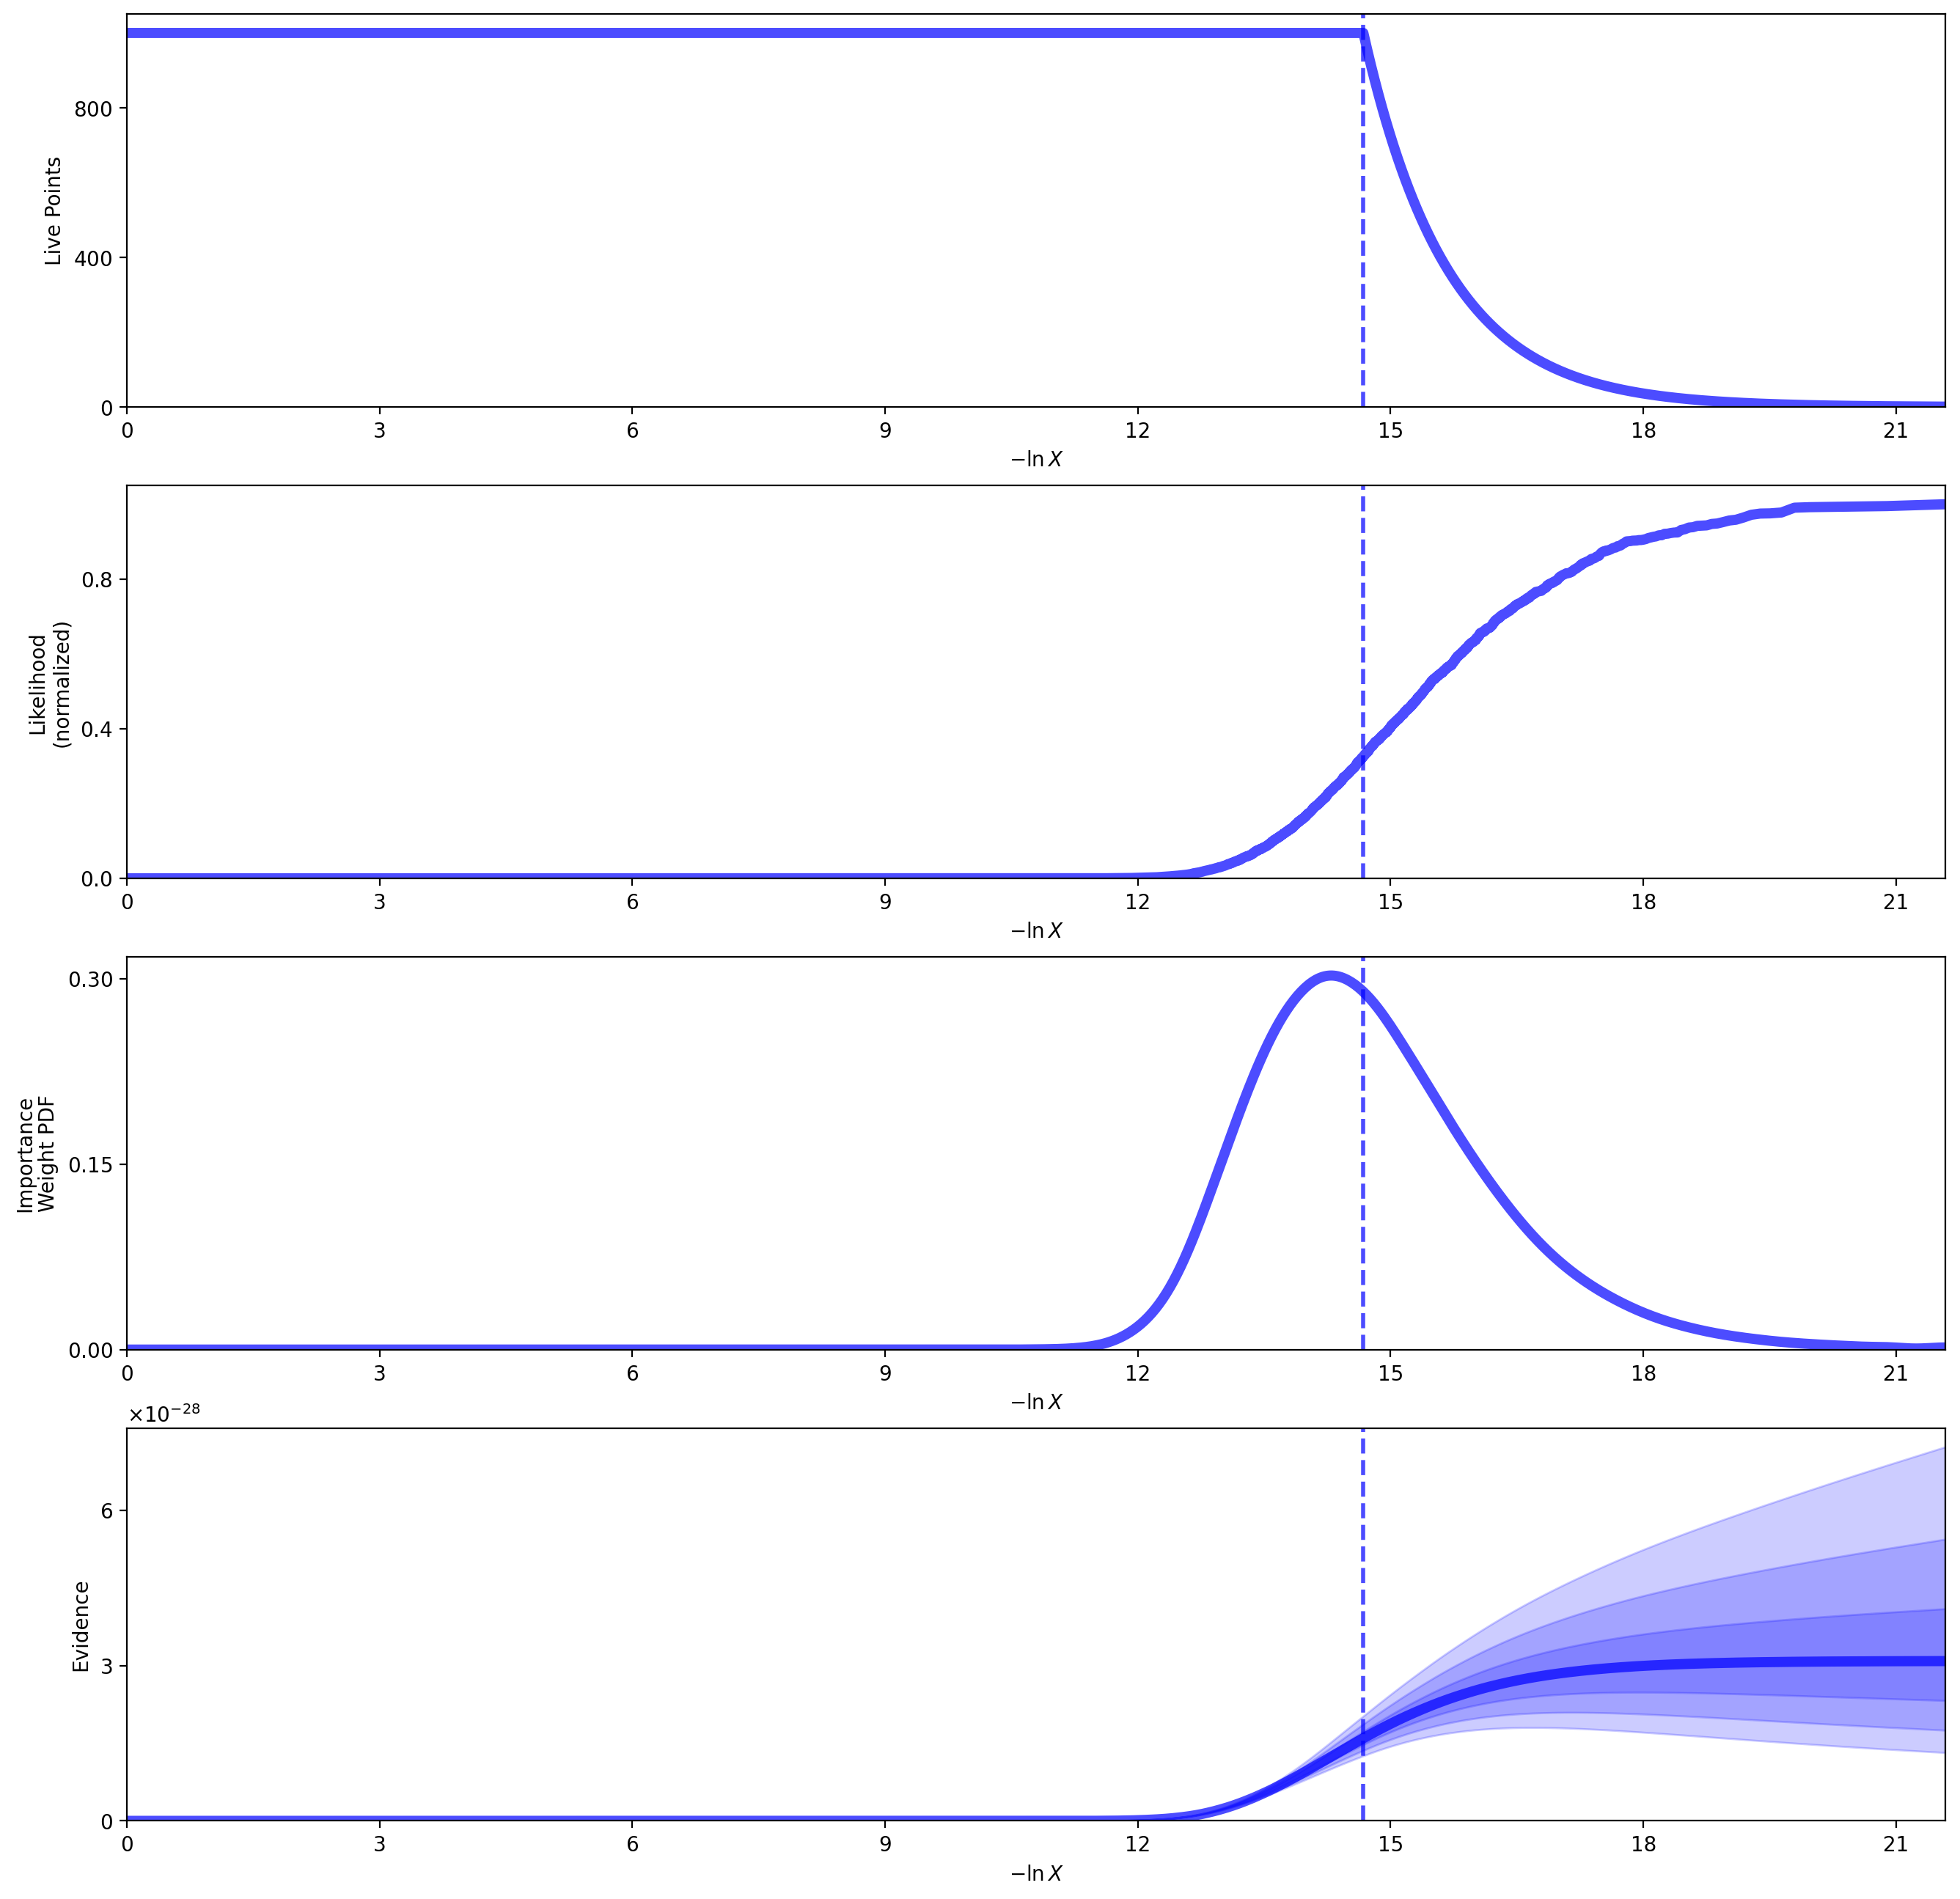

In [8]:
rfig, raxes = dyplot.runplot(sresults)

visualize traceplots to check if sampler converged and to visualize posterior distributions of parameters: 
- x1=b
- x2=A
- x3=t0
- x4=alpha

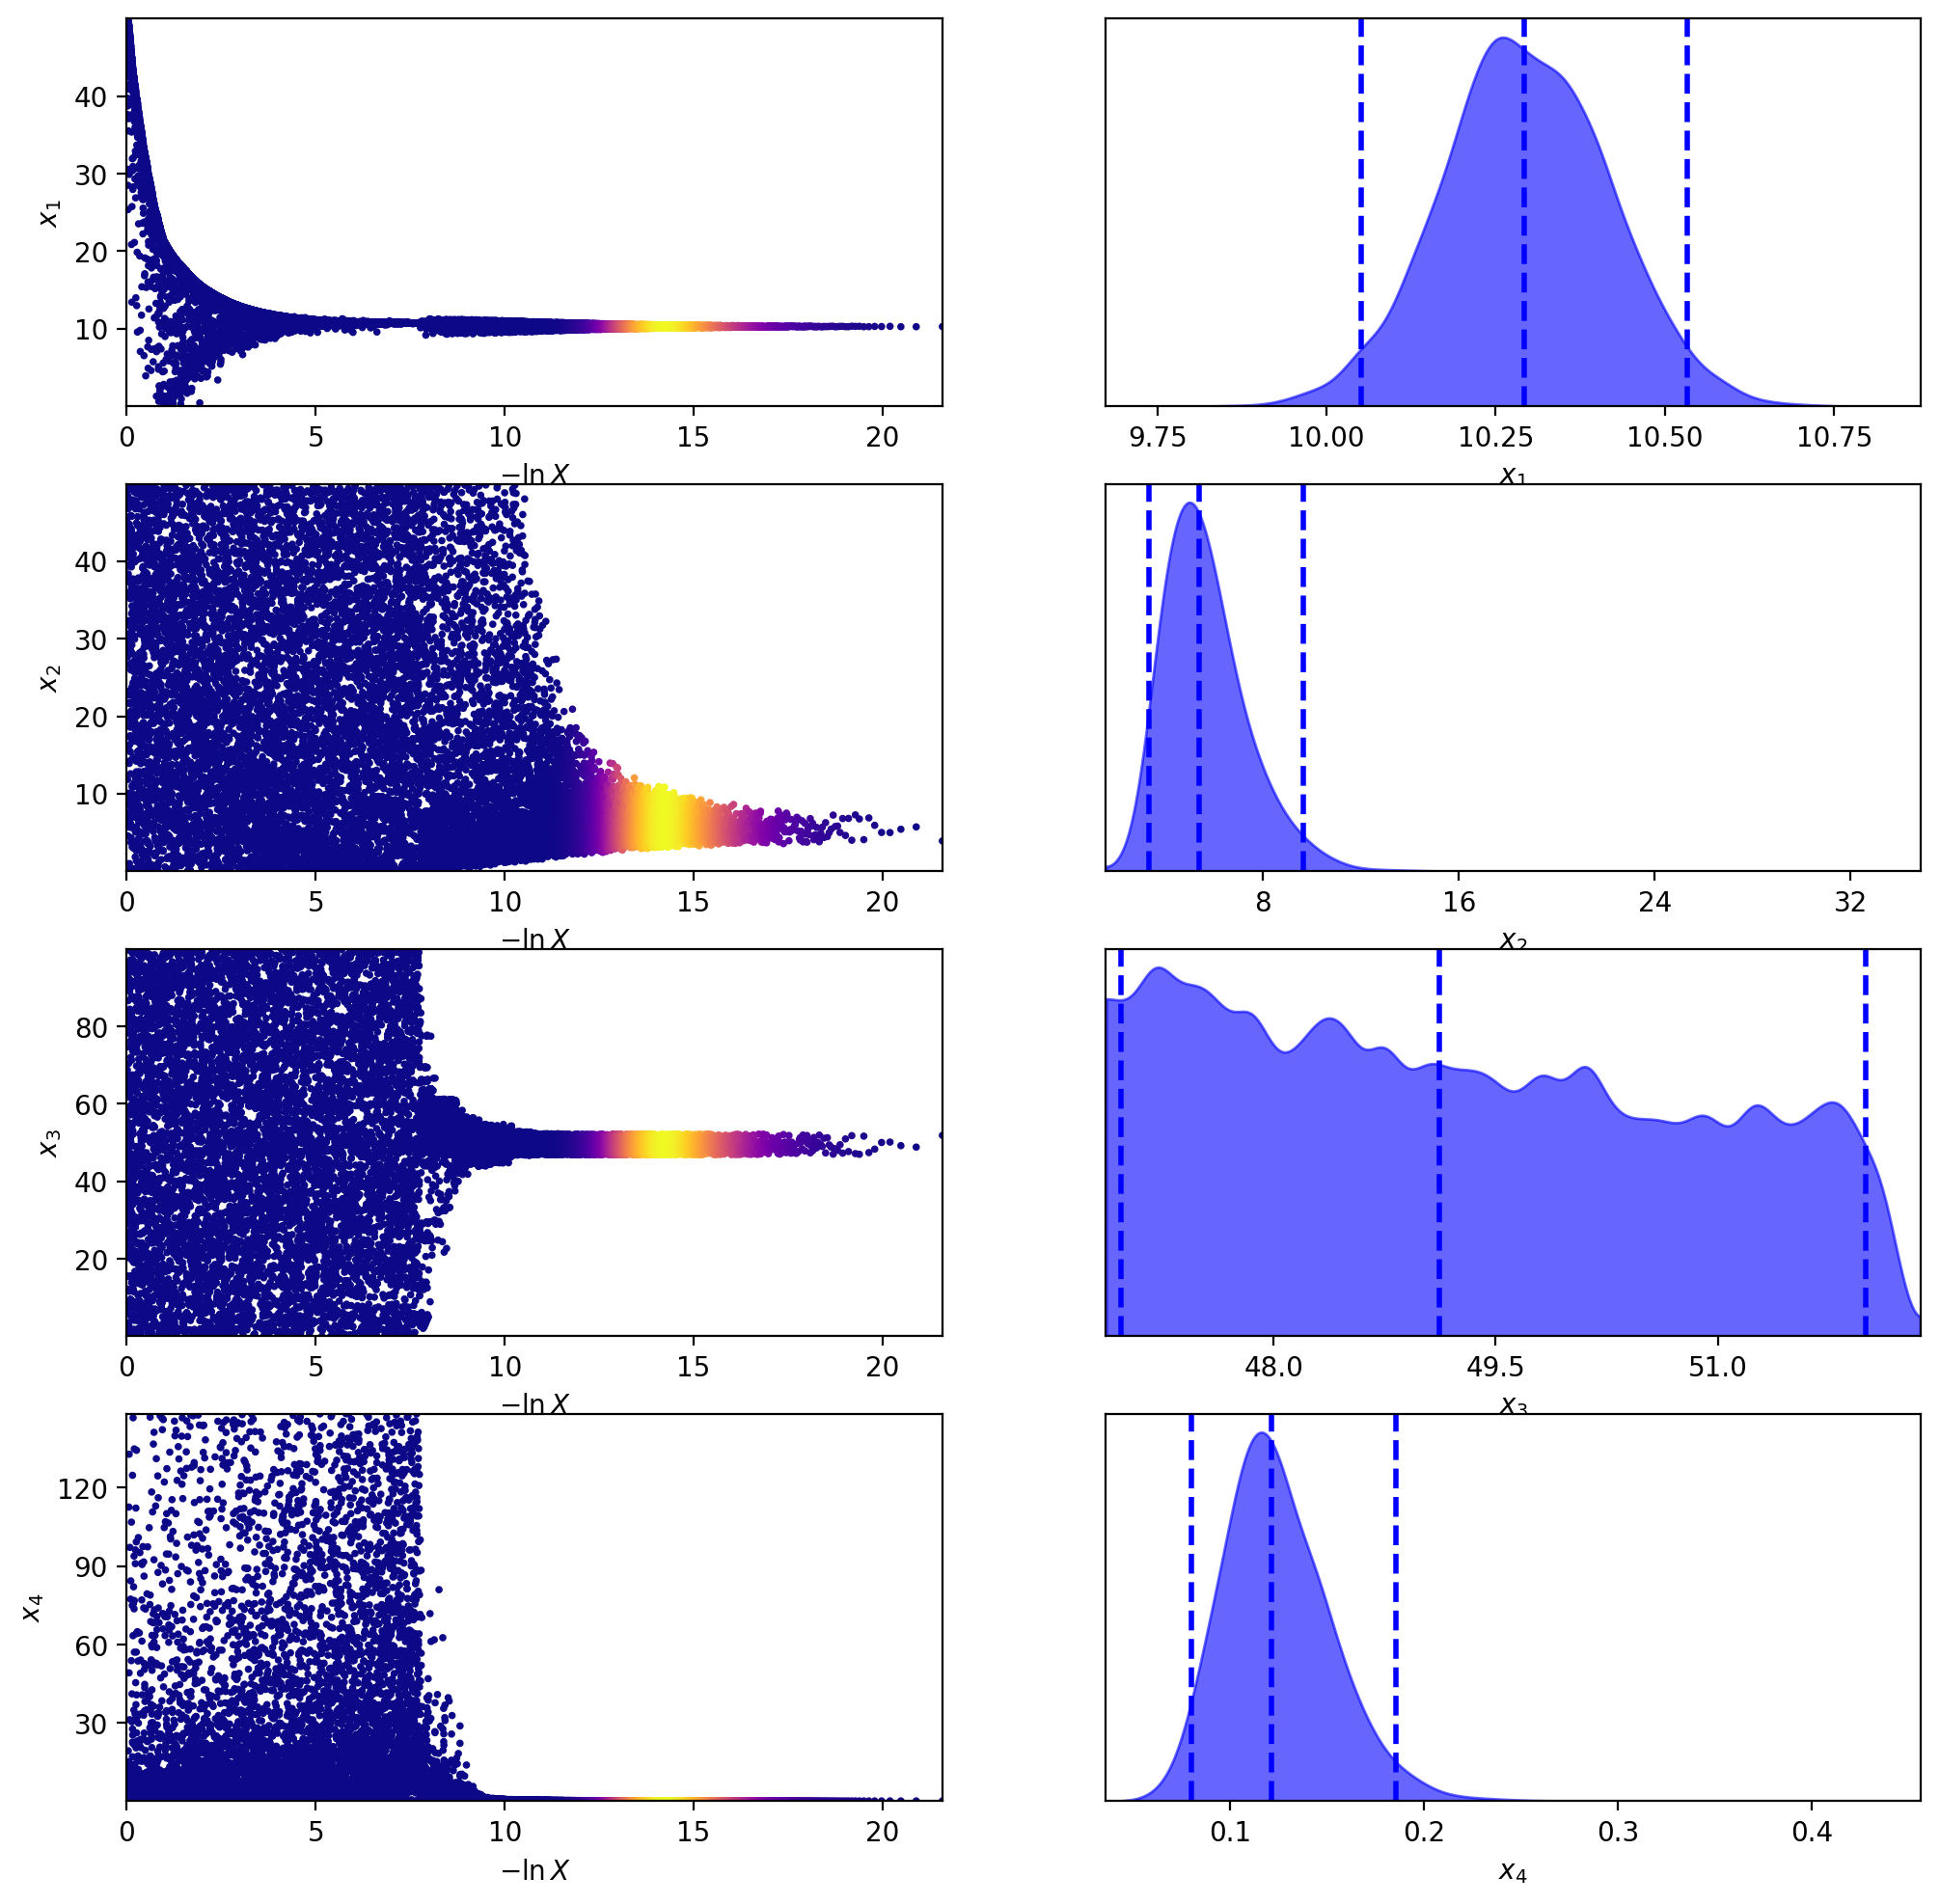

In [9]:
tfig, taxes = dyplot.traceplot(sresults)

Nested sampling returns weighted samples, so I compute weights in order to correct samples for their weights and visualize corner plot (with median and quantiles)

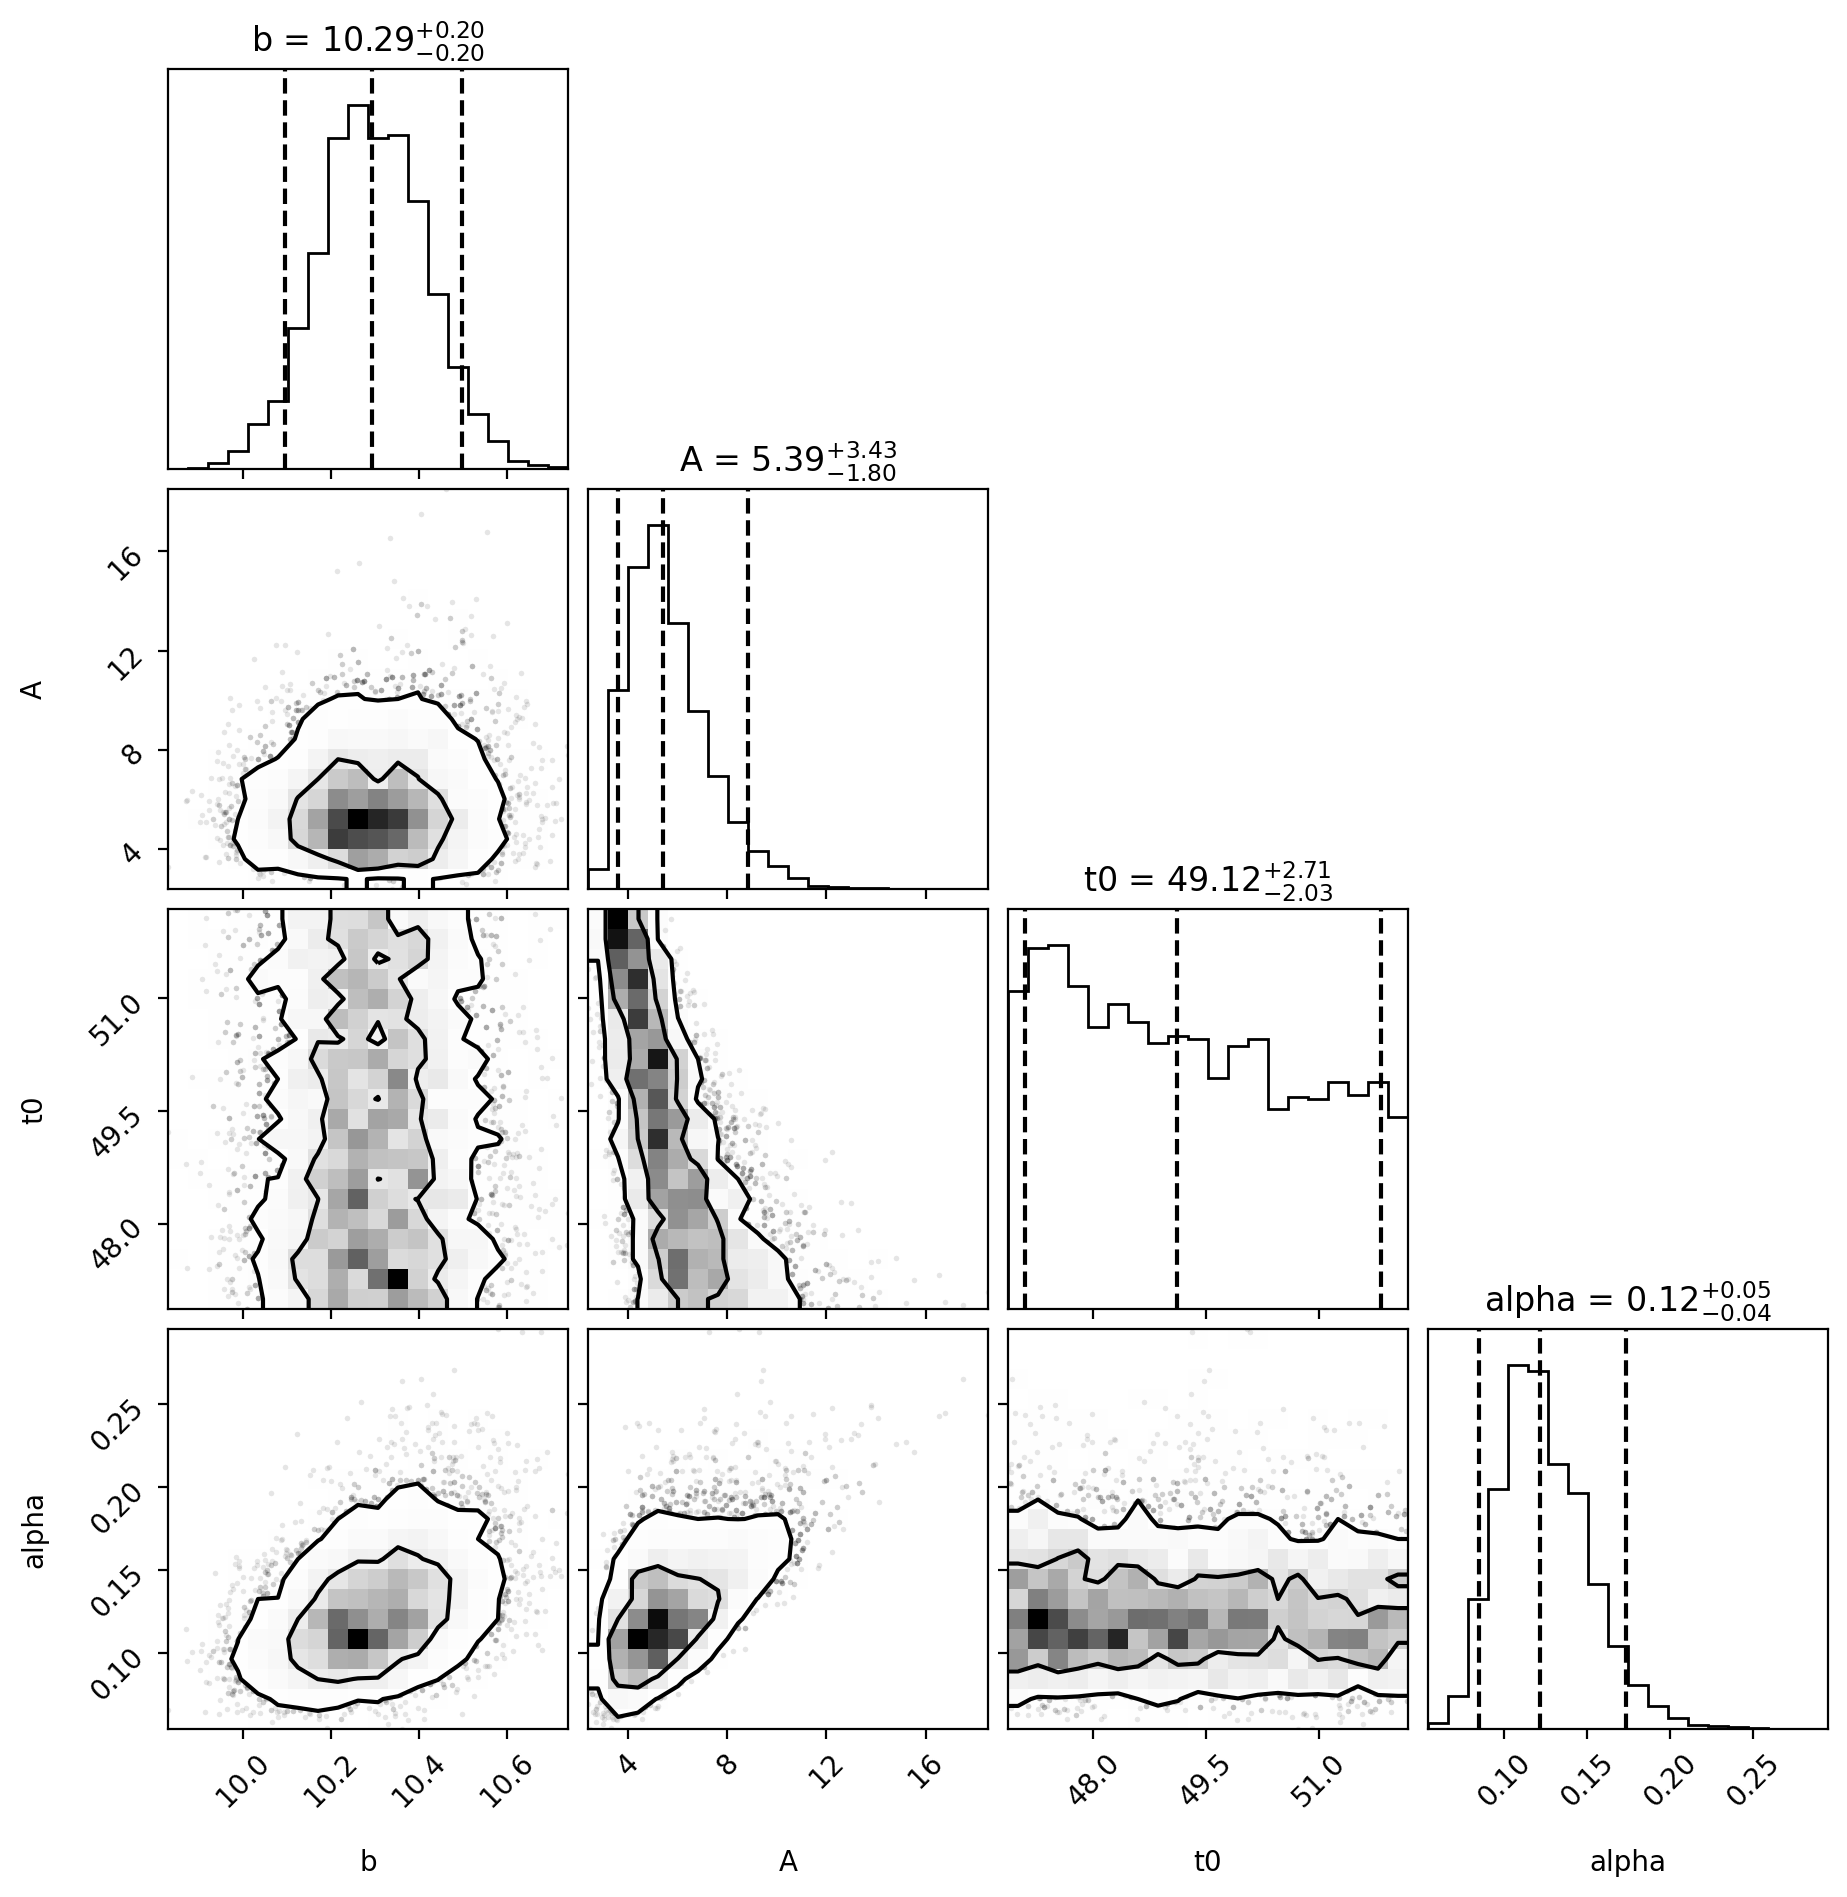

In [29]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

labels = ["b","A","t0","alpha"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels, levels=[0.68,0.95],
                   quantiles=[0.05, 0.5, 0.95], show_titles=True, title_fmt=".2f",
                   plot_density=True);

Recovered parameters with 90% credible regions 

In [11]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

b   10.292485658278046 +0.20442703193834966 -0.19785479768942338
A   5.391278000721946 +3.430135274523489 -1.7960476823901024
t0   49.11953910872838 +2.7168711314627245 -2.032577217327905
alpha   0.12134344721490173 +0.05223331230300443 -0.036442731139460185


The results agree with those obtained in L11

Compute the LogEvidence

In [12]:
burst_log_evidence = sresults.logz[-1]           #log-evidence
burst_log_evidence_error = sresults.logzerr[-1]  #log-evidence error

#compute the evidence
burst_evidence = np.exp(burst_log_evidence)
print("Bayesian evidence for Burst:", burst_evidence)

#propagate the error 
burst_evidence_error = burst_evidence * burst_log_evidence_error
print("Bayesian evidence error for Burst:", burst_evidence_error)

Bayesian evidence for Burst: 3.0848580923604857e-28
Bayesian evidence error for Burst: 8.745436541194669e-29


In [13]:
sresults.summary()

Summary
nlive: 1000
niter: 14683
ncall: 230060
eff(%):  6.817
logz: -63.346 +/-  0.283


# Gaussian profile model

Now MCMC sampling with NestedSampling using dynesty and a gaussian profile model

In [21]:
sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'gauss'],ptform_args=['gauss'],nlive=1000)
sampler.run_nested()
sresultsG = sampler.results

9595it [12:43,  5.25it/s, bound: 91 | nc: 101 | ncall: 171575 | eff(%):  5.592 | loglstar:   -inf < -75.886 <    inf | logz: -87.468 +/-  0.102 | dlogz: 24.881 >  1.009]    /Users/beatricetonello/opt/anaconda3/lib/python3.11/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
15410it [14:47, 17.36it/s, +1000 | bound: 108 | nc: 1 | ncall: 198073 | eff(%):  8.327 | loglstar:   -inf < -52.423 <    inf | logz: -67.833 +/-  0.133 | dlogz:  0.001 >  1.009]


visualize traceplots and posterior distributions of parameters

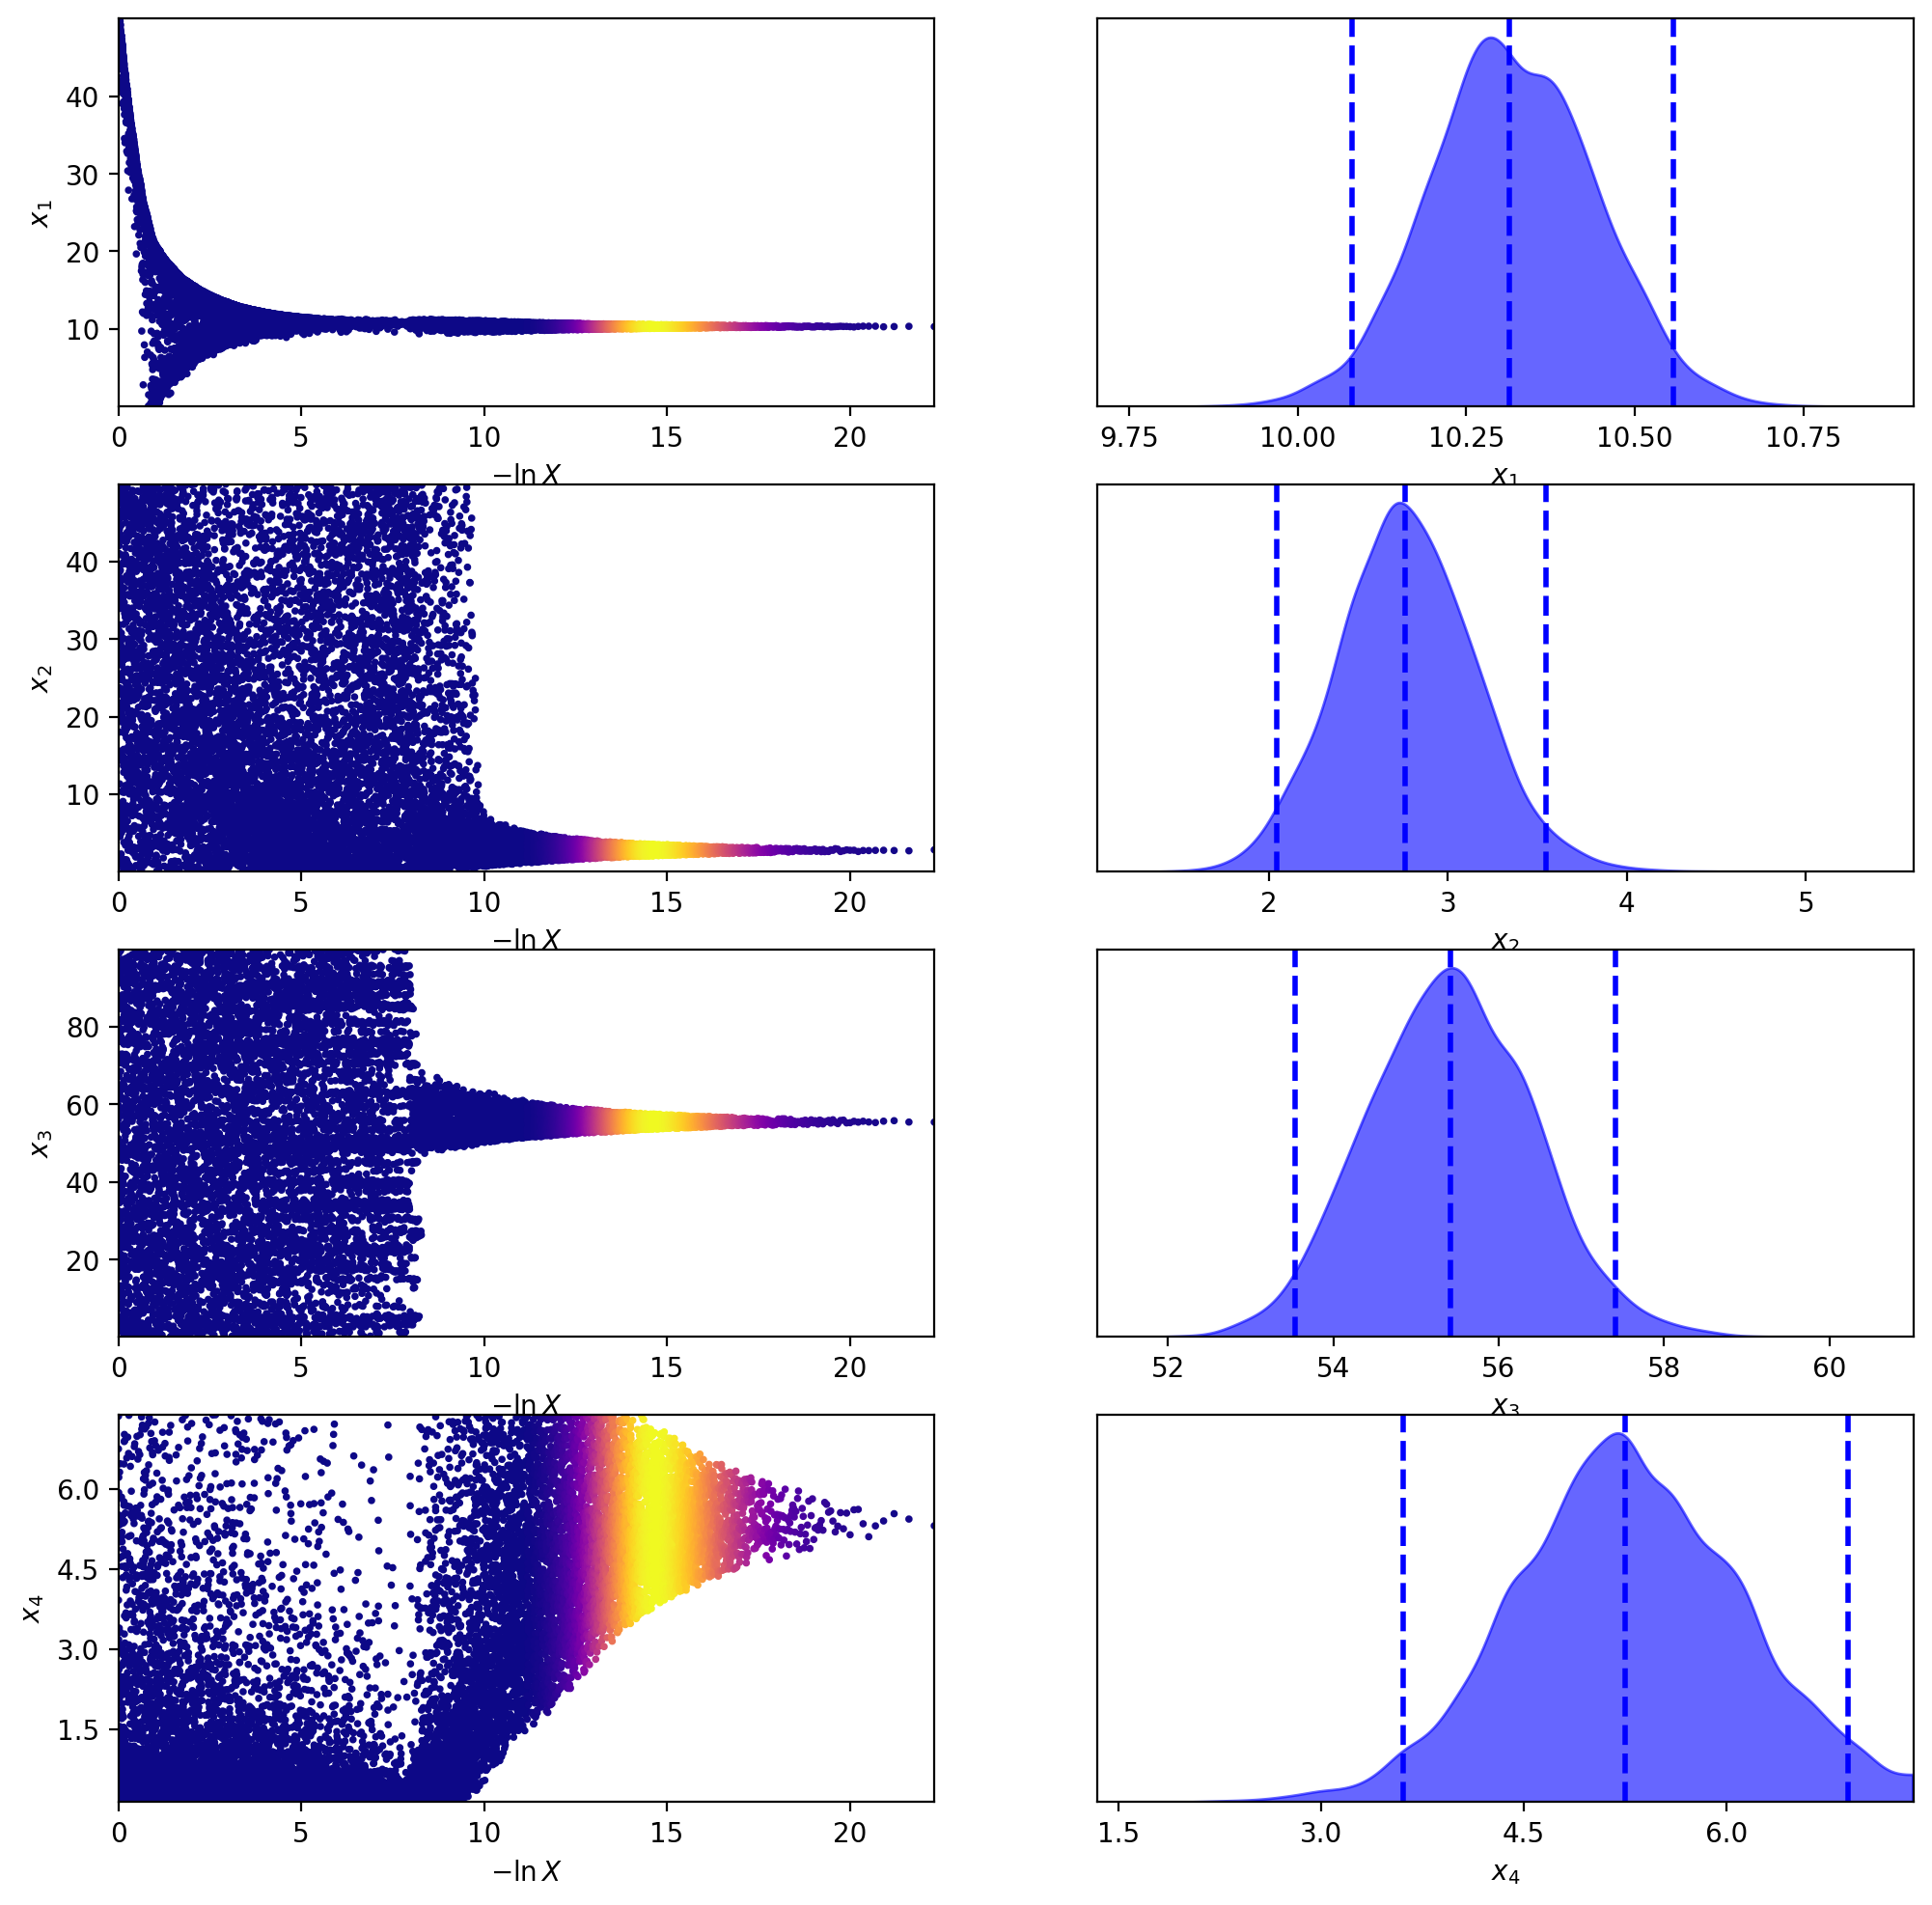

In [22]:
tfig, taxes = dyplot.traceplot(sresultsG)

Correct samples for their weights and visualize corner plot with median and quantiles

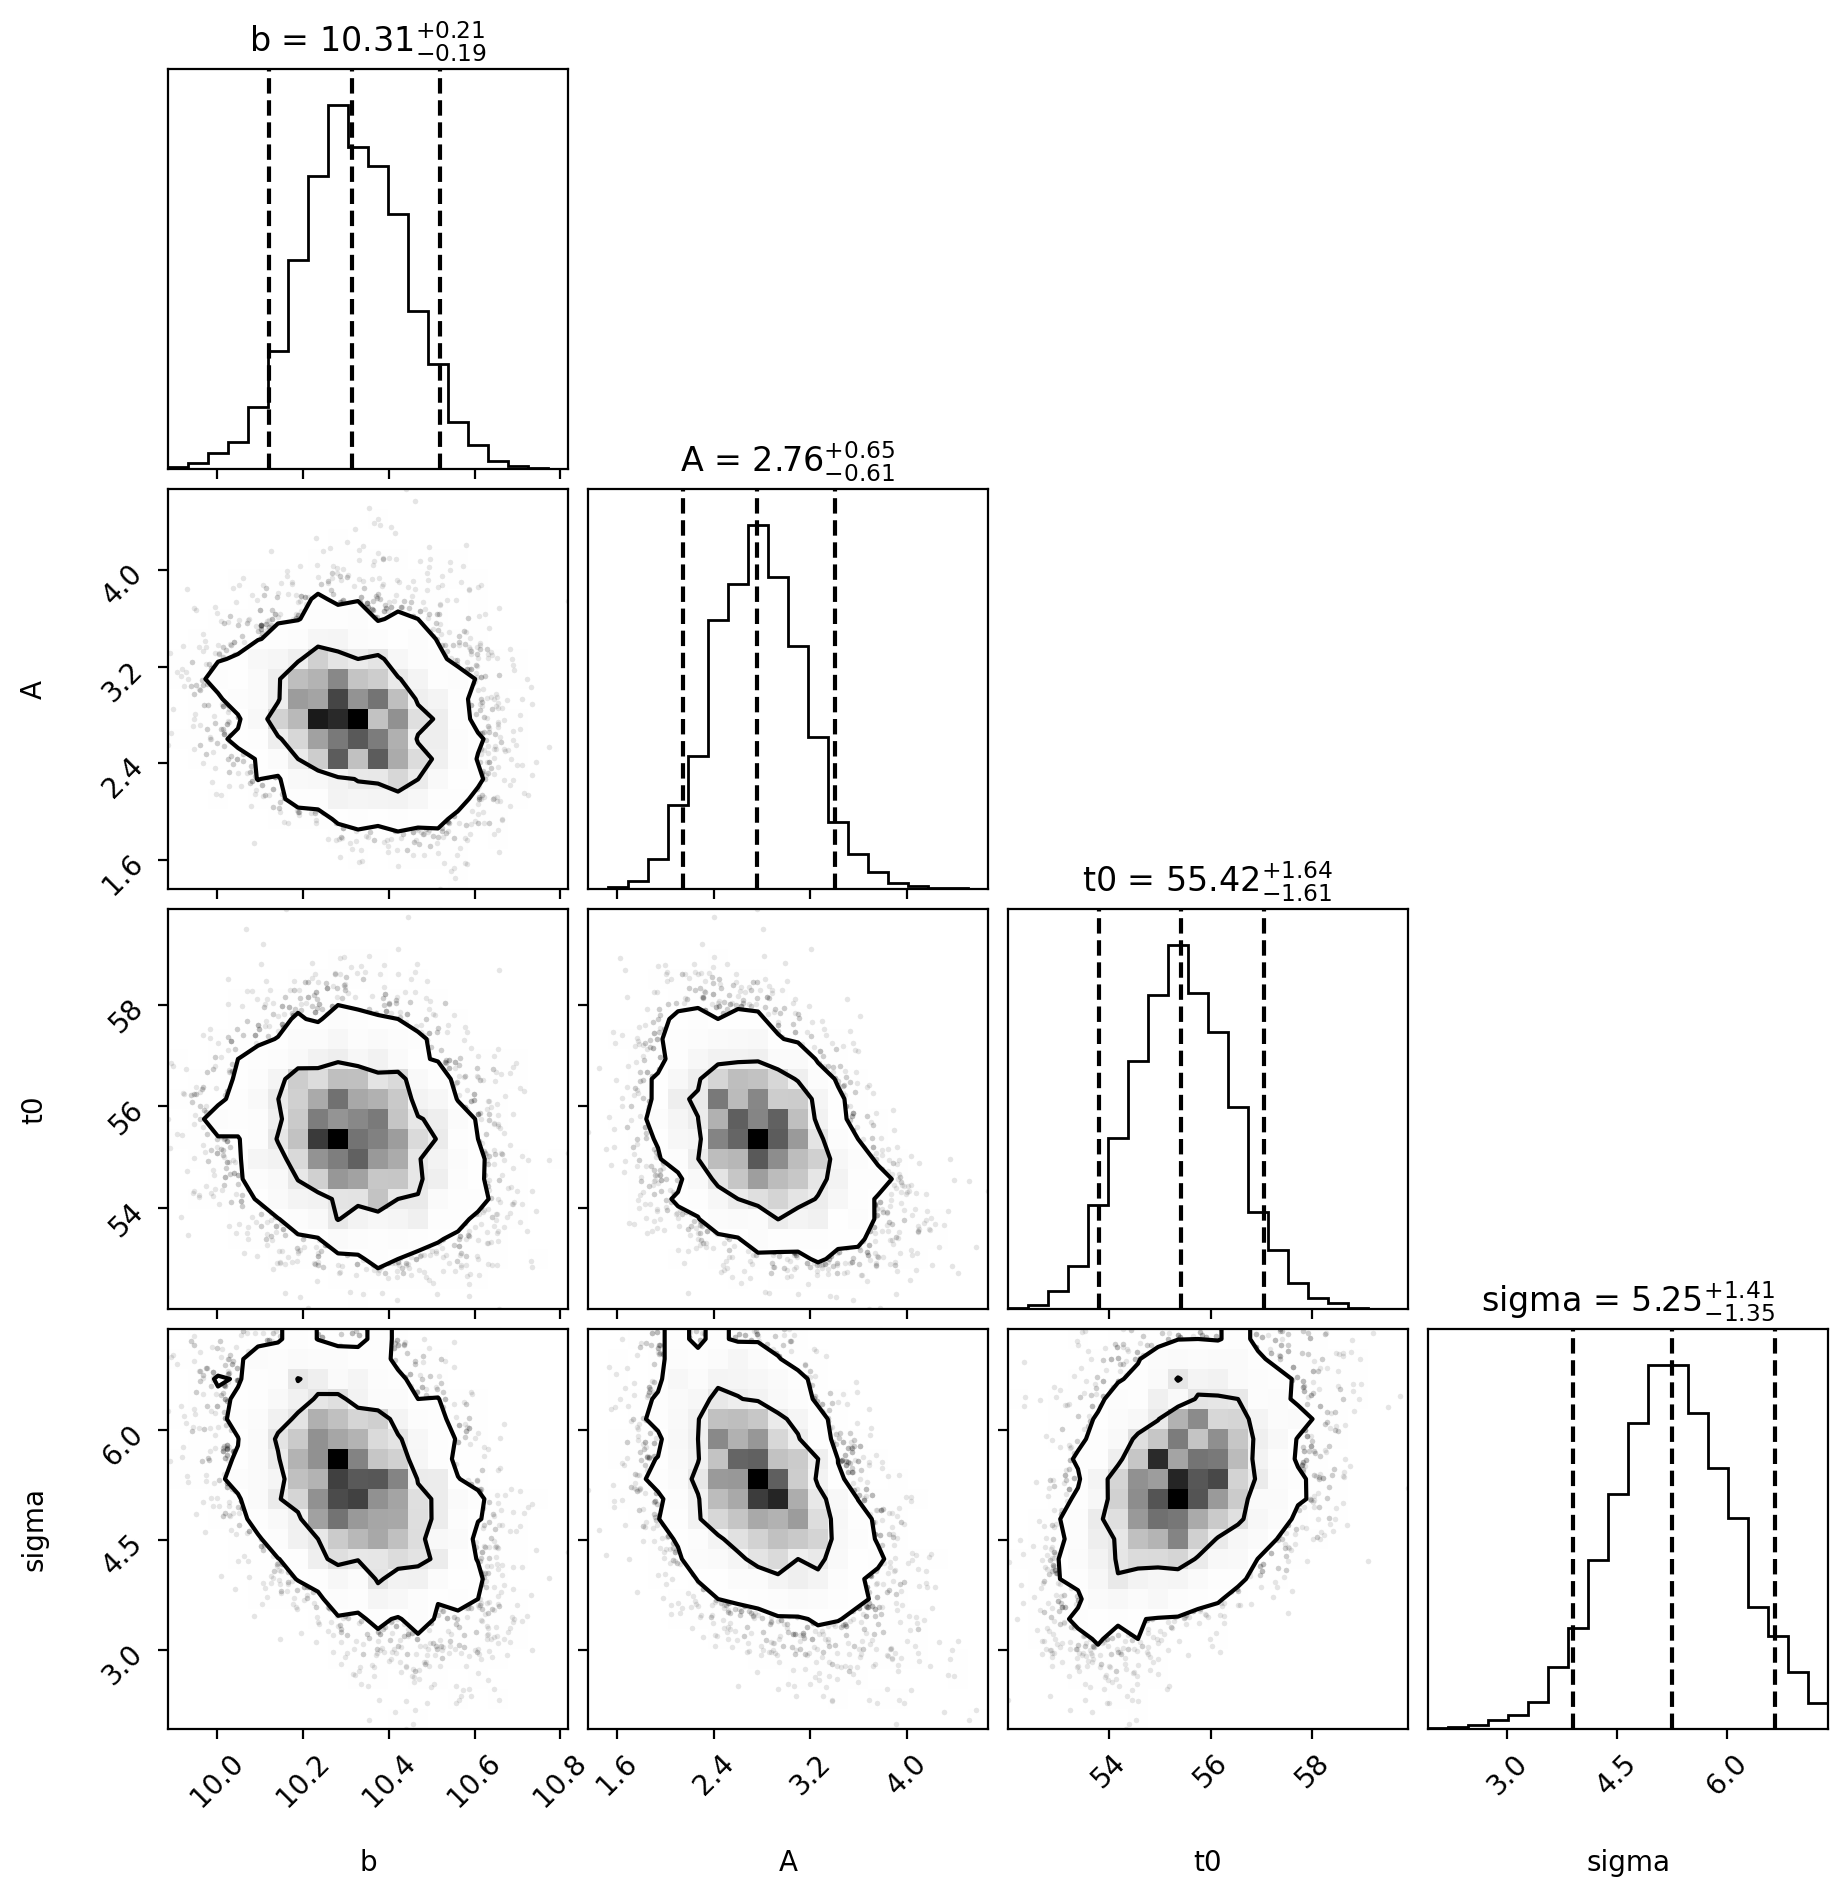

In [30]:
samplesG = sresultsG.samples  # samples
weightsG = np.exp(sresultsG.logwt - sresultsG.logz[-1])  # normalized weights

labels = ["b","A","t0","sigma"]

samples_equalG = dyfunc.resample_equal(samplesG, weightsG)
corner.corner(samples_equalG,labels=labels, levels=[0.68,0.95],
                   quantiles=[0.05, 0.5, 0.95], show_titles=True, title_fmt=".2f",
                   plot_density=True);

In [24]:
quantilesG = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weightsG)
             for samps in samplesG.T]
for q,l in zip(quantilesG,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

b   10.314428623125405 +0.20689999756233846 -0.19311521465975545
A   2.758385029867577 +0.646270284520083 -0.6124527378716476
t0   55.415793277573265 +1.6318116557221813 -1.6021949804033326
sigma   5.248351734438517 +1.4094089373187417 -1.3503323304511068


These results are different from those recovered with the burst porfile

Now I compute evidence 

In [25]:
burst_log_evidence = sresultsG.logz[-1]           #log-evidence
burst_log_evidence_error = sresultsG.logzerr[-1]  #log-evidence error

#compute the evidence
burst_evidence = np.exp(burst_log_evidence)
print("Bayesian evidence for Burst:", burst_evidence)

#propagate the error 
burst_evidence_error = burst_evidence * burst_log_evidence_error
print("Bayesian evidence error for Burst:", burst_evidence_error)

Bayesian evidence for Burst: 3.469648419406047e-30
Bayesian evidence error for Burst: 1.0092374531390343e-30


In [26]:
sresultsG.summary()

Summary
nlive: 1000
niter: 15410
ncall: 197073
eff(%):  8.327
logz: -67.833 +/-  0.291


# odds ratio

In [27]:
print(np.exp(sresults.logz[-1])/np.exp(sresultsG.logz[-1]))

88.90981792583378


The odds ratio gives "very strong" (31<B<100) evidence in favour of burst model